In [ ]:
# ---------- Cell 1 : 基础配置与依赖导入 ----------
import os
import re
import random
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from tqdm import tqdm
import sys
import pykeen.pipeline as pk_pipeline

# ========= 1. 基础配置 ========= #
INPUT_CSV = "AIBL.csv"
PREFIX = "distmult_AIBL" 

# 严格保持原来的32维
EMBED_DIM = 32
SEED = 2025
FEATURE_START_IDX = 2

# 保留 mmse, cdr, lm_imm, lm_del 作为特征节点
# 因此这里只剔除元数据和疾病诊断标签
EXCLUDE_COLS = {
    'path', 'filename', 'visit', 'Tesla', 
    'NC', 'MCI', 'DE', 'COG', 'AD', 'PD', 'FTD', 'VD', 'DLB', 'PDD', 'ADD', 'OTHER'
}

# 中间训练用的 TSV 文件
TRIPLE_TRAIN = f"train_{PREFIX}.tsv"
TRIPLE_VALID = f"valid_{PREFIX}.tsv"
TRIPLE_TEST = f"test_{PREFIX}.tsv"

# 最终输出的模型和映射文件名称
ENTITY2ID_PATH = "CustomKG-AIBL.txt"
REL2ID_PATH = "relation2id_CustomKG-AIBL.txt" 
EMB_PATH = "CustomKG-AIBL.npy"

# 固定随机种子
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("✅ Cell 1: 基础配置与依赖加载完成。输出文件已设定为 CustomKG-AIBL 系列。")

✅ Cell 1: 基础配置与依赖加载完成。输出文件已设定为 CustomKG-AIBL 系列。


In [3]:
# ---------- Cell 2 : 辅助函数与特征图谱构建 ----------
def sanitize(text: str) -> str:
    return re.sub(r"\s+", "_", str(text).strip())

def extract_ptid_from_filename(filename_str):
    # 根据AIBL数据格式提取ID，如有差异请调整正则
    match = re.search(r"(\d+_S_\d+)", str(filename_str))
    if match:
        return match.group(1)
    return str(filename_str)

def age_bin(age):
    try:
        a = float(age)
    except:
        return "age_unknown"
    lo = int(a // 10 * 10)
    return f"age_{lo}_{lo + 9}"

def get_triples_for_patient(row: pd.Series):
    """
    生成纯特征三元组，防止数据泄露，同时保留设定的BIO量表
    """
    h = sanitize(row['PTID'])
    feature_triples = []

    if "gender" in row and pd.notna(row["gender"]):
        feature_triples.append((h, "has_gender", sanitize(row["gender"])))
    if "age" in row and pd.notna(row["age"]):
        feature_triples.append((h, "has_age_bin", age_bin(row["age"])))

    for col in row.index[FEATURE_START_IDX:]:
        if col in EXCLUDE_COLS or col.lower() in ['age', 'gender', 'ptid']:
            continue

        v = row[col]
        if pd.isna(v) or str(v).strip() in ("", "nan"):
            continue

        col_name = sanitize(col)
        val_str = sanitize(v)
        feature_triples.append((h, f"has_{col_name}", val_str))

    return feature_triples

print(f">> Loading data from {INPUT_CSV} ...")
if not Path(INPUT_CSV).exists():
    print(f"Error: File not found {INPUT_CSV}")
else:
    df = pd.read_csv(INPUT_CSV)
    
    if 'filename' not in df.columns:
        raise ValueError(f"{INPUT_CSV} 中缺少 'filename' 列，无法提取ID")
    
    df['PTID'] = df['filename'].apply(extract_ptid_from_filename)
    
    all_triples = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="   Parsing Data"):
        feats = get_triples_for_patient(row)
        all_triples.extend(feats)
        
    print(f"\n✅ Cell 2: 数据解析完成。共提取到无监督特征三元组总数: {len(all_triples)}")

>> Loading data from AIBL.csv ...


   Parsing Data: 100%|██████████| 516/516 [00:00<00:00, 13222.51it/s]


✅ Cell 2: 数据解析完成。共提取到无监督特征三元组总数: 3612


In [4]:
# ---------- Cell 3 : 随机切分三元组与保存中间文件 ----------
# 随机打乱三元组
random.shuffle(all_triples)

n_total = len(all_triples)
n_test = int(n_total * 0.10)
n_valid = int(n_total * 0.10)

final_test = all_triples[:n_test]
final_valid = all_triples[n_test:n_test + n_valid]
final_train = all_triples[n_test + n_valid:]

print(f"\n>> Triples Stats:")
print(f"   Train Triples: {len(final_train):,}")
print(f"   Valid Triples: {len(final_valid):,}")
print(f"   Test  Triples: {len(final_test):,}")

# 保存为 PyKeen 需要的 TSV 格式
def save_tsv(path, triples):
    with open(path, "w", encoding="utf-8") as f:
        for h, r, t in triples: 
            f.write(f"{h}\t{r}\t{t}\n")

save_tsv(TRIPLE_TRAIN, final_train)
save_tsv(TRIPLE_VALID, final_valid)
save_tsv(TRIPLE_TEST, final_test)

print("\n✅ Cell 3: 数据集切分与 TSV 保存完成，准备进入模型训练。")


>> Triples Stats:
   Train Triples: 2,890
   Valid Triples: 361
   Test  Triples: 361

✅ Cell 3: 数据集切分与 TSV 保存完成，准备进入模型训练。


In [7]:
# ---------- Cell 4 : PyKeen 训练、提取 Loss、评估指标与保存 ----------
import os
import torch
import numpy as np

print("\n>> Starting DistMult training ...")

# 自动检测设备
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"   Using device: {device}")

# 启动 PyKeen 训练管线 (严格使用已设定的 32 维)
result = pk_pipeline.pipeline(
    model="DistMult",
    training=TRIPLE_TRAIN,
    validation=TRIPLE_VALID,
    testing=TRIPLE_TEST,
    model_kwargs=dict(embedding_dim=EMBED_DIM),
    training_kwargs=dict(num_epochs=100, batch_size=256),
    stopper="early",
    stopper_kwargs=dict(frequency=5, patience=10, relative_delta=0.002),
    evaluator_kwargs=dict(filtered=True),
    negative_sampler="basic",
    random_seed=SEED,
    device=device,
    training_loop="SLCWA",
)

print("\n>> Training Finished.")

# ================= 提取训练 Loss =================
train_losses = result.training_loop.losses_per_epochs
np.save("CustomKG-AIBL-Losses.npy", train_losses)

# ================= 提取测试集标准评估指标 (KGE 领域标准) =================
# 获取 MRR 和 Hits@K
mrr = result.metric_results.get_metric('mrr')
hits_10 = result.metric_results.get_metric('hits@10')
hits_3 = result.metric_results.get_metric('hits@3')
hits_1 = result.metric_results.get_metric('hits@1')

test_metrics = {'MRR': mrr, 'Hits@10': hits_10, 'Hits@3': hits_3, 'Hits@1': hits_1}
np.save("CustomKG-AIBL-TestMetrics.npy", test_metrics)

print("\n==========================================")
print("     CustomKG-AIBL 测试集预测指标评估")
print("==========================================")
print(f"MRR (Mean Reciprocal Rank): {mrr:.4f}")
print(f"Hits@10: {hits_10:.4f}")
print(f"Hits@3:  {hits_3:.4f}")
print(f"Hits@1:  {hits_1:.4f}")
print("==========================================")

# ================= 保存嵌入和映射字典 =================
model = result.model
entity_embs = model.entity_representations[0]().cpu().detach().numpy()

np.save(EMB_PATH, entity_embs)

with open(ENTITY2ID_PATH, "w", encoding="utf-8") as f:
    for e, i in result.training.entity_to_id.items():
        f.write(f"{e}\t{i}\n")

with open(REL2ID_PATH, "w", encoding="utf-8") as f:
    for r, i in result.training.relation_to_id.items():
        f.write(f"{r}\t{i}\n")

print(f"\n✅ 嵌入与映射文件均已严格保存！")

INFO:pykeen.pipeline.api:Using device: cpu
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)
INFO:pykeen.stoppers.early_stopping:Inferred checkpoint path for best model weights: C:\Users\HP\.data\pykeen\checkpoints\best-model-weights-33fe2517-0771-4a26-ab2e-62aa728d19a7.pt



>> Starting DistMult training ...
   Using device: cpu


d:\Anaconda\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training epochs on cpu:   0%|          | 0/100 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0.00/12.0 [00:00<?, ?batch/s]

...

Training batches on cpu:   0%|          | 0.00/12.0 [00:00<?, ?batch/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 0.07s seconds
INFO:pykeen.stoppers.early_stopping:New best result at epoch 100: 0.3656509695290859. Saved model weights to C:\Users\HP\.data\pykeen\checkpoints\best-model-weights-33fe2517-0771-4a26-ab2e-62aa728d19a7.pt
INFO:pykeen.training.training_loop:=> Saved checkpoint after having finished epoch 100.


Evaluating on cpu:   0%|          | 0.00/361 [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 0.08s seconds



>> Training Finished.

     CustomKG-AIBL 测试集预测指标评估
MRR (Mean Reciprocal Rank): 0.2379
Hits@10: 0.4114
Hits@3:  0.2535
Hits@1:  0.1537

✅ 嵌入与映射文件均已严格保存！


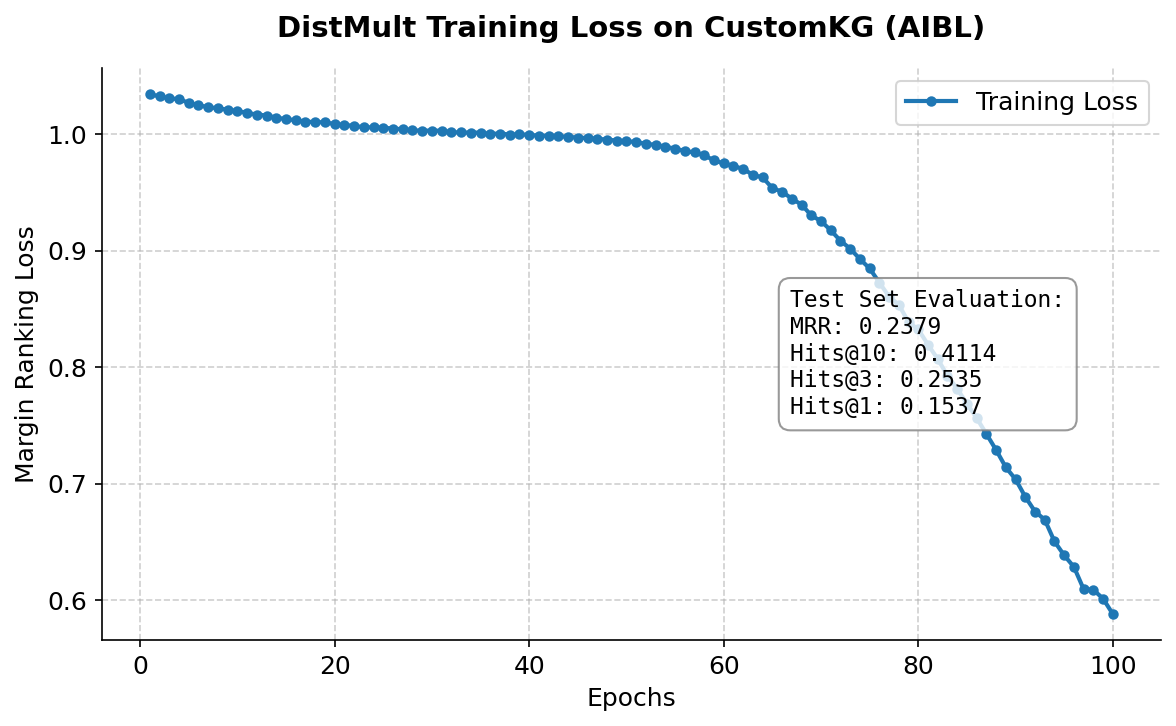

✅ Loss 曲线绘制完成！图表已包含测试集指标，高清图像已保存至: CustomKG-AIBL-LossCurve-with-Metrics.png


In [8]:
# ---------- Cell 5 : 绘制并保存训练 Loss 曲线 (带测试指标) ----------
import matplotlib.pyplot as plt
import numpy as np

# 读取 Loss 数据和测试指标
try:
    train_losses = np.load("CustomKG-AIBL-Losses.npy")
    test_metrics = np.load("CustomKG-AIBL-TestMetrics.npy", allow_pickle=True).item()
except FileNotFoundError:
    print("❌ 找不到文件，请确保 Cell 4 已成功运行。")
    train_losses = []

if len(train_losses) > 0:
    plt.rcParams.update({'font.size': 12})
    
    fig, ax = plt.subplots(figsize=(8, 5), dpi=150)
    
    # 绘制训练 Loss 曲线
    epochs = range(1, len(train_losses) + 1)
    ax.plot(epochs, train_losses, color='#1f77b4', linewidth=2, linestyle='-', marker='o', markersize=4, label='Training Loss')
    
    ax.set_title('DistMult Training Loss on CustomKG (AIBL)', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Epochs', fontsize=12)
    ax.set_ylabel('Margin Ranking Loss', fontsize=12)
    
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(loc='upper right')
    
    # 在图表中嵌入测试集评估指标 (画龙点睛之笔)
    metrics_text = (
        "Test Set Evaluation:\n"
        f"MRR: {test_metrics['MRR']:.4f}\n"
        f"Hits@10: {test_metrics['Hits@10']:.4f}\n"
        f"Hits@3: {test_metrics['Hits@3']:.4f}\n"
        f"Hits@1: {test_metrics['Hits@1']:.4f}"
    )
    
    # 将指标文本框放置在图表内部（中右侧），防止阻挡曲线
    props = dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray')
    ax.text(0.65, 0.5, metrics_text, transform=ax.transAxes, fontsize=11,
            verticalalignment='center', bbox=props, fontfamily='monospace')
    
    plt.tight_layout()
    
    img_path = "CustomKG-AIBL-LossCurve-with-Metrics.png"
    plt.savefig(img_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Loss 曲线绘制完成！图表已包含测试集指标，高清图像已保存至: {img_path}")